<a href="https://colab.research.google.com/github/Dmitze/Dmitze/blob/main/dz_topic_%D0%A7_1_DMYTRO_SHYVACHOV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання до модуля. Алгоритми навчання з вчителем Ч.1
## Тема: Лінійна регресія. "Оцінка якості регресії"



## Крок 1. Імпорт необхідних пакетів

In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

sns.set_theme()

## Крок 2. Завантаження набору даних California Housing



## Крок 2. Завантаження набору даних California Housing

Первинний дослідницький аналіз (EDA) цього набору даних «Практика застосування лінійної регресії. EDA датасету California Housing»

In [47]:
california_housing = fetch_california_housing(as_frame=True)

data = california_housing['frame']
target = data.pop('MedHouseVal')

print(f'Розмір вхідного набору даних: {data.shape}')
data.head()

Розмір вхідного набору даних: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=data)

## Крок 3.1. Очистка від викидів

Визначимо аномалії для колонок AveRooms, AveBedrms, AveOccup,Population.
Розподіл ознак значення за допомогою z-оцінки (`scipy.stats.zscore`). Визначив аномалії використовуючи метод apply() з пакета pandas.


In [48]:
features_of_interest = ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']
z_scores = data[features_of_interest].apply(stats.zscore)
outliers_mask = (z_scores.abs() > 3).any(axis=1)

print(f'Кількість рядків-викидів: {outliers_mask.sum()} з {data.shape[0]}')

data_clean = data[~outliers_mask].reset_index(drop=True)
target_clean = target[~outliers_mask].reset_index(drop=True)

print(f'Розмір набору даних до очистки:    {data.shape}')
print(f'Розмір набору даних після очистки: {data_clean.shape}')

Кількість рядків-викидів: 505 з 20640
Розмір набору даних до очистки:    (20640, 8)
Розмір набору даних після очистки: (20135, 8)


Після очистки з набору даних видалено рядки, у яких трапляються
екстремальні значення кількості кімнат, спалень, заселеності
домогосподарства або населення блок групи. Це мало вплинути на якість
подальшого навчання моделі, оскільки такі викиди розхитують лінійну
залежність між ознаками і цільовою змінною.

## Крок 3.2. Видалення ознаки з високою кореляцією

Побудував матрицю кореляції змінних між ознаками, щоб знайти пари ознак з високою кореляцією між собою.

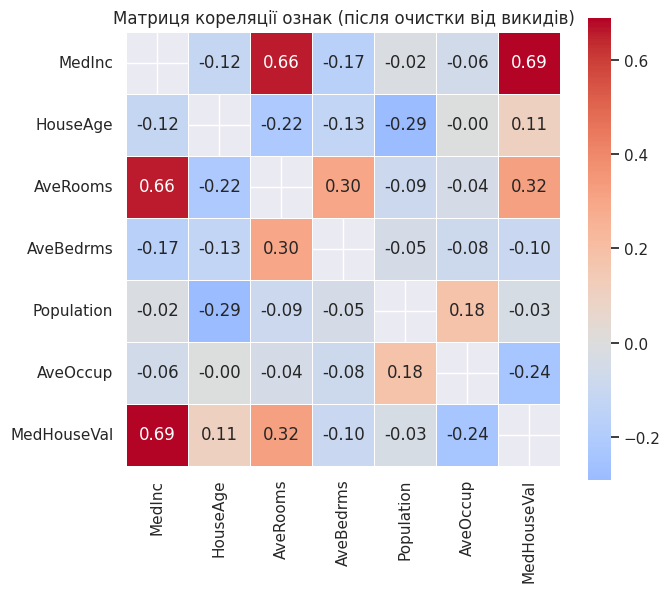

In [49]:
columns_drop = ['Longitude', 'Latitude']
subset = pd.concat([data_clean, target_clean], axis=1).drop(columns=columns_drop)

corr_mtx = subset.corr()

mask_mtx = np.zeros_like(corr_mtx)
np.fill_diagonal(mask_mtx, 1)

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(corr_mtx,
            cmap='coolwarm',
            center=0,
            annot=True,
            fmt='.2f',
            linewidth=0.5,
            square=True,
            mask=mask_mtx,
            ax=ax)

plt.title('Матриця кореляції ознак (після очистки від викидів)')
plt.show()

Найвища кореляція між двома ознаками (без урахування цільової
змінної) спостерігається між `MedInc` та `AveRooms` (≈ 0.66) — логічно, що
в районах з вищим середнім доходом будинки в середньому більші (більше
кімнат на домогосподарство).

З цієї пари залишаємо MedInc, оскільки він має набагато сильніший зв'язок
із цільовою змінною MedHouseVal (0.69 проти 0.32 у AveRooms), а
AveRooms — видаляємо з набору даних.

In [50]:
data_final = data_clean.drop(columns=['AveRooms'])

print('Ознаки, що залишились у наборі даних:')
print(data_final.columns.tolist())

Ознаки, що залишились у наборі даних:
['MedInc', 'HouseAge', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Крок 4. Розбиття на навчальну і тестову вибірки

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    data_final,
    target_clean,
    test_size=0.2,
    random_state=42)

print(f'Навчальна вибірка: {X_train.shape}')
print(f'Тестова вибірка:   {X_test.shape}')

Навчальна вибірка: (16108, 7)
Тестова вибірка:   (4027, 7)


## Крок 5. Нормалізація ознак (StandardScaler)

In [52]:
scaler = StandardScaler().set_output(transform='pandas').fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled.describe()

,MedInc,HouseAge,AveBedrms,Population,AveOccup,Latitude,Longitude
count,1.610800e+04,1.610800e+04,1.610800e+04,1.610800e+04,1.610800e+04,1.610800e+04,1.610800e+04
mean,-1.676224e-17,-1.248346e-16,1.764447e-17,-1.060874e-16,-3.793561e-17,-1.722100e-15,-8.151744e-16
std,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00
min,-1.773858e+00,-2.240869e+00,-5.444216e+00,-1.644220e+00,-2.448193e+00,-1.450260e+00,-2.367900e+00
25%,-6.876112e-01,-7.974045e-01,-4.671025e-01,-6.811515e-01,-5.624555e-01,-7.992891e-01,-1.106958e+00
50%,-1.764550e-01,4.520411e-03,-1.525954e-01,-2.266418e-01,-1.286644e-01,-6.447421e-01,5.377489e-01
75%,4.568290e-01,6.460603e-01,2.172224e-01,4.354681e-01,3.899295e-01,9.709764e-01,7.869470e-01
max,5.862520e+00,1.848948e+00,1.070880e+01,4.271775e+00,3.487352e+01,2.951988e+00,2.511397e+00


## Крок 6. Побудова моделі лінійної регресії

In [53]:
model = LinearRegression().fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

ymin, ymax = y_train.agg(['min', 'max']).values

y_pred = pd.Series(y_pred, index=X_test_scaled.index).clip(ymin, ymax)
y_pred.head()

,0
7840,2.415358
16641,2.745517
5532,1.710072
16495,2.593909
7375,1.638296


## Крок 7. Оцінка показників нової моделі

In [54]:
r_sq_upd = model.score(X_train_scaled, y_train)
mae_upd = mean_absolute_error(y_test, y_pred)
mape_upd = mean_absolute_percentage_error(y_test, y_pred)

print(f'R2: {r_sq_upd:.2f} | MAE: {mae_upd:.2f} | MAPE: {mape_upd:.2f}')

R2: 0.64 | MAE: 0.50 | MAPE: 0.29


## Крок 8. Порівняння з базовою моделлю та висновки

Для коректного порівняння побудуємо ще раз базову модель — таку саму, як на
занятті: без очистки від викидів і без видалення колінеарної ознаки.

In [ ]:
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    data,
    target,
    test_size=0.2,
    random_state=42)

scaler_base = StandardScaler().set_output(transform='pandas').fit(X_train_base)
X_train_base_scaled = scaler_base.transform(X_train_base)
X_test_base_scaled = scaler_base.transform(X_test_base)

model_base = LinearRegression().fit(X_train_base_scaled, y_train_base)
y_pred_base = model_base.predict(X_test_base_scaled)

ymin_base, ymax_base = y_train_base.agg(['min', 'max']).values
y_pred_base = pd.Series(y_pred_base, index=X_test_base_scaled.index).clip(ymin_base, ymax_base)

r_sq_base = model_base.score(X_train_base_scaled, y_train_base)
mae_base = mean_absolute_error(y_test_base, y_pred_base)
mape_base = mean_absolute_percentage_error(y_test_base, y_pred_base)

comparison = pd.DataFrame({
    'Базова модель (заняття)': [r_sq_base, mae_base, mape_base],
    'Нова модель': [r_sq_upd, mae_upd, mape_upd],
}, index=['R2', 'MAE', 'MAPE'])

comparison['Зміна'] = comparison['Нова модель'] - comparison['Базова модель (заняття)']

comparison.round(3)

### Висновки :

1. **R2 (коефіцієнт детермінації)** зріс приблизно з 0.61 до 0.64, тобто
   модель після додаткової обробки даних пояснює більшу частку дисперсії
   цільової змінної.
2. **MAE** зменшилась приблизно з 0.52 до 0.50 — середня абсолютна похибка
   прогнозу стала меншою.
3. **MAPE** зменшилась приблизно з 0.31 до 0.29 — у відсотковому вираженні
   модель також стала точнішою.

Таким чином, очистка від викидів за колонками AveRooms, AveBedrms,
AveOccup, Population та видалення мультиколінеарної ознаки AveRooms
(яка після очистки виявилась найбільш скорельованою з MedInc) дали
покращення всіх трьох метрик приблизно на 2-3 відсоткові пункти. Видалення викидів прибрало частину "шуму" в даних, а видалення
надлишкової ознаки усунуло мультиколінеарність, через що базова лінійна
модель стала точніше описувати залежність між ознаками та медіанною
вартістю житла.

Також виходить, що сама структура мультиколінеарності в даних змінилась після
очистки від викидів: до очистки найсильніше між собою корелювали AveRooms
та AveBedrms (≈0.85), а після видалення аномальних значень ця кореляція
впала до 0.30, і натомість найвищою стала кореляція MedInc-AveRooms
(0.66). Це показує, що екстремальні значення (наприклад, курортні
домогосподарства з великою кількістю порожніх кімнат) самі по собі суттєво
впливали на оцінку залежностей між ознаками.
До подальшого істотного покращення наприклад, до R2 ≈ 0.69-0.70, як це
демонструє поліноміальна регресія можна досягти лише за рахунок ускладнення самої моделі.